In [53]:
import numpy as np
import pandas as pd
import plotly.express as px
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


import sys
sys.path.append("../..")
from src.utils import mark_repeated_columns

# Configs
import plotly.io as pio
pio.templates.default = "plotly_dark"

In [2]:
# Data
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")
df = df.loc[:, ~mark_repeated_columns(df)[1]] # remove days with repeated values (due to anomalies like Ash Wednesday)

In [3]:
fig = px.line(
    df,
    color_discrete_sequence=['#80ed99'],  
    title="Returns by tick")

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.show()

In [4]:
df_realized_volatility = df**2

fig = px.line(
    df_realized_volatility,
    color_discrete_sequence=['#80ed99'],
    title="Realized volatility"
    )

fig.update_layout(
    legend_title_text='Curve'
)
fig.update_traces(opacity=.4)
fig.update_layout(yaxis=dict(exponentformat='power'))
fig.show()

In [35]:
vol = df_realized_volatility.sum()
log_vol = np.log(vol)
log_vol.name = "logVol"

In [57]:
df_realized_volatility.sum(axis=0)

2024-12-02    0.000055
2024-12-03    0.000064
2024-12-04    0.000039
2024-12-05    0.000105
2024-12-06    0.000037
                ...   
2025-11-24    0.000032
2025-11-25    0.000062
2025-11-26    0.000049
2025-11-27    0.000011
2025-11-28    0.000037
Length: 247, dtype: float64

# Scores

In [36]:
scores_path = "../../data/processed/dfpc_scores.xlsx"
df_scores = pd.read_excel(scores_path).set_index("index")
# n1_scores = df_scores.iloc[:,1]
# n1_scores.index = df_scores["index"]

In [37]:
df_vol_scores = pd.concat([log_vol, df_scores], axis=1)

In [38]:
# df_vol_scores = pd.DataFrame(
#                         {
#                         "log_vol": log_vol.values,
#                         "scores":  n1_scores.values
#                         }, index=log_vol.index,
#                         )
df_vol_scores.corr(method="pearson")

,logVol,$η_1$,$η_2$,$η_3$,$η_4$,$η_5$
logVol,1.000000,0.900843,-0.077699,-0.217669,0.109995,0.234868
$η_1$,0.900843,1.000000,-0.108019,0.034234,0.022707,0.229480
$η_2$,-0.077699,-0.108019,1.000000,0.024804,-0.020438,-0.327926
$η_3$,-0.217669,0.034234,0.024804,1.000000,0.053647,0.053784
$η_4$,0.109995,0.022707,-0.020438,0.053647,1.000000,-0.163307
$η_5$,0.234868,0.229480,-0.327926,0.053784,-0.163307,1.000000


In [45]:
# df_vol_scores = pd.DataFrame(
#                         {
#                         "log_vol": log_vol.values,
#                         "scores":  n1_scores.values
#                         }, index=log_vol.index,
#                         )
df_vol_scores.corr(method="pearson")
fig = px.scatter_matrix(
    df_vol_scores,
    width=1000,
    height=1000
    )
fig.update_traces(showlowerhalf=False)
fig.show()

In [ ]:
fig = px.scatter(x=df_scores.iloc[:,2], y=log_vol)
fig.show()

In [50]:
log_vol

2024-12-02    -9.807073
2024-12-03    -9.662751
2024-12-04   -10.162805
2024-12-05    -9.163072
2024-12-06   -10.194079
                ...    
2025-11-24   -10.358015
2025-11-25    -9.685622
2025-11-26    -9.916756
2025-11-27   -11.449665
2025-11-28   -10.194550
Name: logVol, Length: 247, dtype: float64

In [49]:
fig = px.scatter(x=df_scores.iloc[:,1].shift(1), y=log_vol)
fig.show()

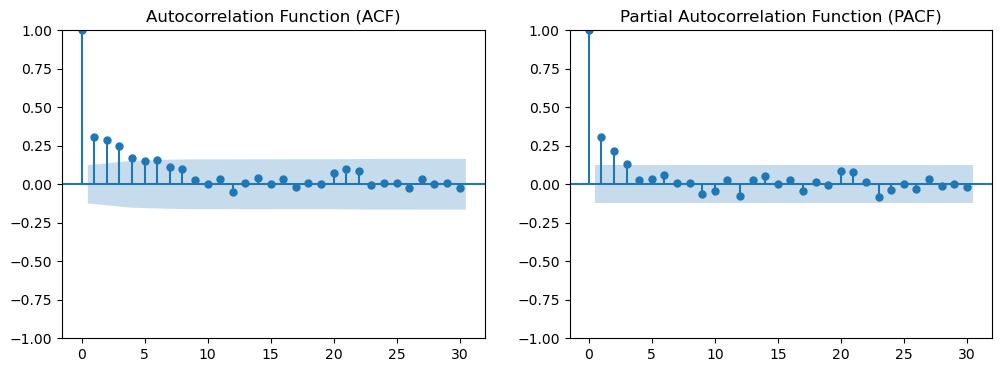

In [54]:
import matplotlib.pyplot as plt

# 2. Create subplots for displaying both graphs side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 3. Plot the ACF
# The 'lags' parameter specifies how many lags to display.
plot_acf(log_vol, lags=30, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# 4. Plot the PACF
# The 'method' parameter can be set to 'ywm' or 'ols' for different estimation methods.
plot_pacf(log_vol, lags=30, ax=axes[1], method='ywm') 
axes[1].set_title('Partial Autocorrelation Function (PACF)')

# 5. Display the plots
plt.show()